<a href="https://colab.research.google.com/github/jessicasalazar/vision_computador/blob/main/cv_taller4_VF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementing Image Rotation Pretext Training for Self Supervised Learning using Keras

In [1]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import random
import os
from PIL import Image
import tensorflow_datasets as tfds
from keras import datasets, layers, models, losses, Model
from random import randint
import shutil


## Load data using a Keras utility
Let's load these images off disk using the helpful tf.keras.utils.image_dataset_from_directory utility.

Create a dataset
Define some parameters for the loader:

In [15]:
batch_size = 32
img_height = 180
img_width = 180

In [16]:
dir(tfds)

['GenerateMode',
 'ImageFolder',
 'ReadConfig',
 'Split',
 'TranslateFolder',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'annotations',
 'as_dataframe',
 'as_numpy',
 'audio',
 'beam',
 'benchmark',
 'builder',
 'builder_cls',
 'builder_from_directories',
 'builder_from_directory',
 'core',
 'd4rl',
 'data_source',
 'dataset_builders',
 'dataset_collection',
 'datasets',
 'decode',
 'deprecated',
 'disable_progress_bar',
 'display_progress_bar',
 'download',
 'enable_progress_bar',
 'even_splits',
 'features',
 'folder_dataset',
 'graphs',
 'image',
 'image_classification',
 'is_dataset_on_gcs',
 'list_builders',
 'list_dataset_collections',
 'load',
 'logging',
 'nearest_neighbors',
 'object_detection',
 'proto',
 'public_api',
 'question_answering',
 'ranking',
 'recommendation',
 'rl_unplugged',
 'rlds',
 'robomimic',
 'robotics',
 'show_examples',
 'show_statistics',
 's

In [17]:
ds_train = tfds.load('cats_vs_dogs', split='train[:80%]', as_supervised=True)
ds_test = tfds.load('cats_vs_dogs', split='train[80%:]', as_supervised=True)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.05WXLO_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [18]:
len(ds_test), len(ds_train)

(4652, 18610)

In [19]:

for image, label in ds_train.take(4):  # example is `{'image': tf.Tensor, 'label': tf.Tensor}`
  print(image.shape, label)

(262, 350, 3) tf.Tensor(1, shape=(), dtype=int64)
(409, 336, 3) tf.Tensor(1, shape=(), dtype=int64)
(493, 500, 3) tf.Tensor(1, shape=(), dtype=int64)
(375, 500, 3) tf.Tensor(0, shape=(), dtype=int64)


## Explore the Dataset

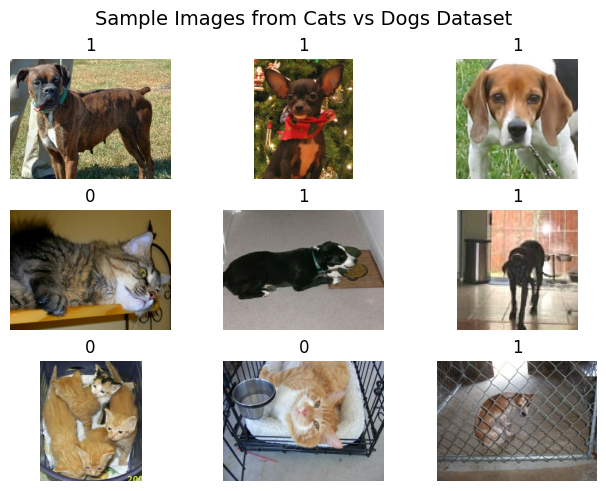

In [20]:
fig, axs = plt.subplots(3,3, layout='constrained')


for (image, label), ax in zip(ds_train.take(9), axs.flat):

  ax.imshow(image.numpy())
  ax.set_title(f"{label.numpy()}")
  ax.axis("off")


plt.suptitle("Sample Images from Cats vs Dogs Dataset", fontsize=14)
plt.show()

In [21]:
rotation_angle = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32) * 90
rotation_angle

<tf.Tensor: shape=(), dtype=int32, numpy=270>

In [22]:
rotation_angle.numpy()

np.int32(270)

In [23]:
def apply_pretext_task(image, _):
    # Example: Randomly rotate image and create rotation label
    image = tf.image.resize(image, [128,128])
    image = tf.cast(image, tf.float32) / 255.0
    rotation_angle = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32) * 90
    rotated_image = tf.image.rot90(image, k=rotation_angle // 90)
    return rotated_image, rotation_angle // 90


In [24]:
ds_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [25]:
pretext_dataset = ds_train.map(apply_pretext_task).batch(32)

In [26]:
import tensorflow as tf


model = keras.models.Sequential([
        keras.layers.Conv2D(64, 7, activation="relu", padding="same",
                            input_shape=[128, 128, 3]),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
        keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(256, 3, activation="relu", padding="same"),
        keras.layers.Conv2D(256, 3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(4, activation="softmax")
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,513,412 (36.29 MB)

 Trainable params: 9,513,412 (36.29 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [29]:
pretext_train = pretext_dataset.take(80)
pretext_val = pretext_dataset.skip(80)
pretext_train = ds_train.map(apply_pretext_task).batch(32)
pretext_val = ds_test.map(apply_pretext_task).batch(32)

In [30]:
for image, label in pretext_train.take(1):
    print("Image shape:", image.shape)
    print("Label shape:", label.shape)

Image shape: (32, 128, 128, 3)
Label shape: (32,)


In [31]:
for _, y in pretext_train.take(1):
    print(y.dtype)

<dtype: 'int32'>


In [32]:
history = model.fit(pretext_train, epochs=10, validation_data=pretext_val)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 77s 104ms/step - accuracy: 0.2578 - loss: 1.3871 - val_accuracy: 0.3083 - val_loss: 1.3817
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 47s 81ms/step - accuracy: 0.2898 - loss: 1.3808 - val_accuracy: 0.3500 - val_loss: 1.3553
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 48s 82ms/step - accuracy: 0.3240 - loss: 1.3629 - val_accuracy: 0.3682 - val_loss: 1.3220
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 82ms/step - accuracy: 0.3528 - loss: 1.3363 - val_accuracy: 0.3841 - val_loss: 1.2996
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 49s 84ms/step - accuracy: 0.3577 - loss: 1.3231 - val_accuracy: 0.3854 - val_loss: 1.2828
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 49s 85ms/step - accuracy: 0.3712 - loss: 1.3148 - val_accuracy: 0.4061 - val_loss: 1.2647
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.3876 - loss: 1.2938 - val_accuracy: 0.4282 - val_loss: 1.2274
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 54s 92ms/step - accuracy: 0.3995 - loss: 1.2700 -

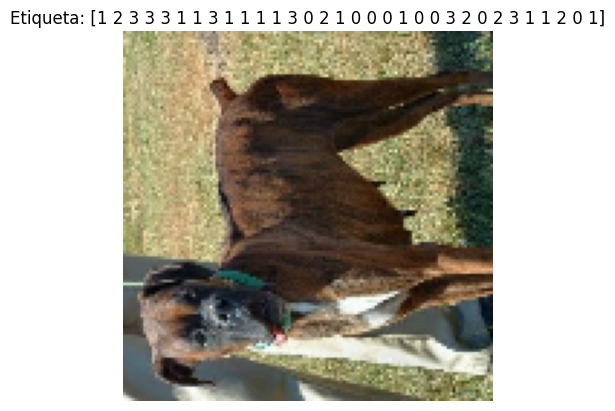

In [39]:
for image, label in pretext_train.take(1):
  plt.imshow((255*image[0].numpy()).astype(np.uint8))       # muestra la primera imagen del batch
  plt.title(f"Etiqueta: {label.numpy()}")
  plt.axis("off")
  plt.show()


## Training Model on Downstream Task
Now that we have out model trained on the Pretext Task, it’s time to train it on the downstream task on which it will be actually evaluated.

We remove the final layer and append a new final layer, a one that has labels corresponding to the downstream task.

In [41]:
model.pop()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,513,154 (36.29 MB)

 Trainable params: 9,513,152 (36.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [42]:
model.add(keras.layers.Dense(2, name='dense_5', activation='softmax'))

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,513,284 (36.29 MB)

 Trainable params: 9,513,282 (36.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [52]:
IMG_SIZE = 128

def format_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalize the pixel values
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))  # Resize to the desired size
    return image, label
batch_size = 32
train_data = ds_train.map(format_image).shuffle(1000).batch(batch_size)
validation_data = ds_test.map(format_image).batch(batch_size)


In [53]:
# Freezing the Convolutional Layers while keeping Dense layers as Trainable
for layer in model.layers:
    if layer.name in ['dense_3', 'dense_1', 'dense', 'dropout', 'dropout_1']:
      layer.trainable=True
    else:
      layer.trainable=False

In [54]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
history = model.fit(train_data, validation_data=validation_data, epochs=100)

Epoch 1/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.5552 - loss: 0.6864 - val_accuracy: 0.6784 - val_loss: 0.6216
Epoch 2/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.6474 - loss: 0.6330 - val_accuracy: 0.6960 - val_loss: 0.5945
Epoch 3/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - accuracy: 0.6810 - loss: 0.6075 - val_accuracy: 0.7027 - val_loss: 0.5805
Epoch 4/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.6919 - loss: 0.5971 - val_accuracy: 0.7064 - val_loss: 0.5721
Epoch 5/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.7069 - loss: 0.5854 - val_accuracy: 0.7066 - val_loss: 0.5639
Epoch 6/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.7105 - loss: 0.5719 - val_accuracy: 0.7201 - val_loss: 0.5596
Epoch 7/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - accuracy: 0.7208 - loss: 0.5641 - val_accuracy: 0.7188 - val_loss: 0.5533
Epoch 8/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.7292 - loss: 0